In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(type(xgb_model))

NameError: name 'xgb_model' is not defined

In [4]:
<class 'xgboost.sklearn.XGBClassifier'>

SyntaxError: invalid syntax (1886254930.py, line 1)

In [5]:
print(type(xgb_model))


NameError: name 'xgb_model' is not defined

In [6]:
print(type(xgb_model))

NameError: name 'xgb_model' is not defined

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

# Remove customer ID
df = df.drop(columns=["customerID"])

# Convert target to 0/1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")
print("Training features:", X.shape[1])

XGBoost model trained successfully!
Training features: 30


In [8]:
import joblib

joblib.dump(xgb_model, "../xgb_model.pkl")
joblib.dump(X.columns.tolist(), "../feature_columns.pkl")

print("Model saved successfully!")
print("Feature columns saved successfully!")

Model saved successfully!
Feature columns saved successfully!


In [9]:
import joblib

joblib.dump(xgb_model, "../xgb_model.pkl")
joblib.dump(X.columns.tolist(), "../feature_columns.pkl")

print("Model saved successfully!")
print("Feature columns saved successfully!")

Model saved successfully!
Feature columns saved successfully!


In [2]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Dataset Shape: (7043, 21)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


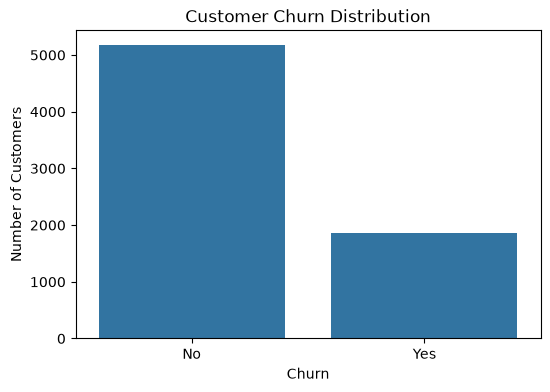

In [3]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

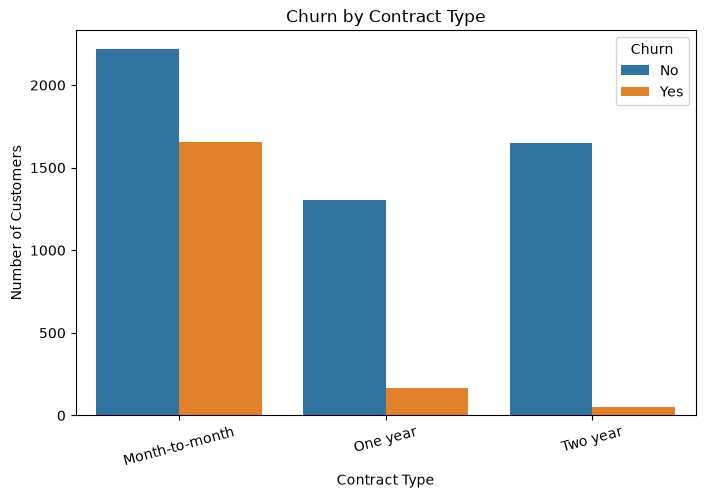

In [4]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

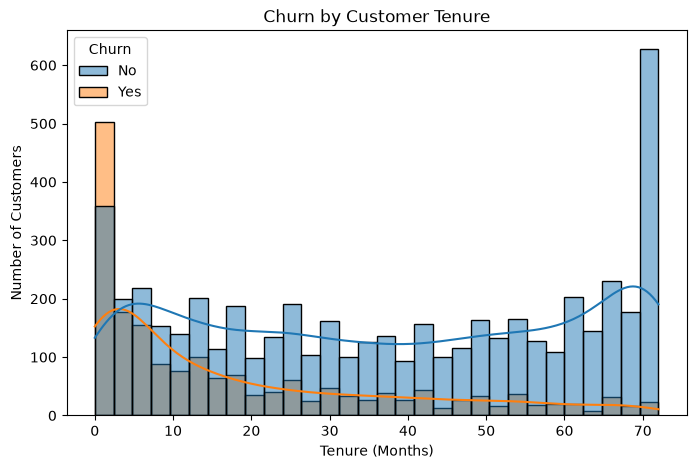

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)

plt.title("Churn by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()


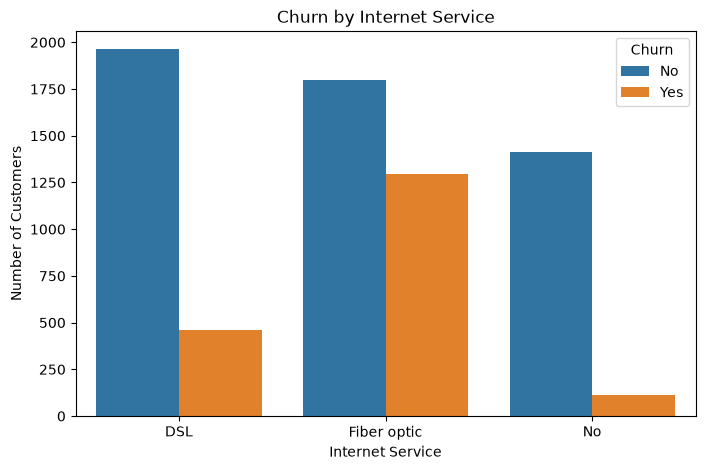

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

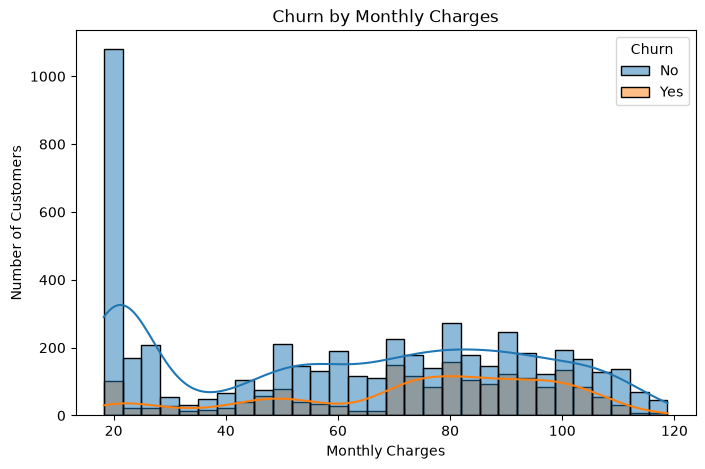

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True)

plt.title("Churn by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].isnull().sum())

11


In [9]:

df = df.dropna(subset=["TotalCharges"])

print("Dataset Shape:", df.shape)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Dataset Shape: (7032, 21)
Missing TotalCharges: 0


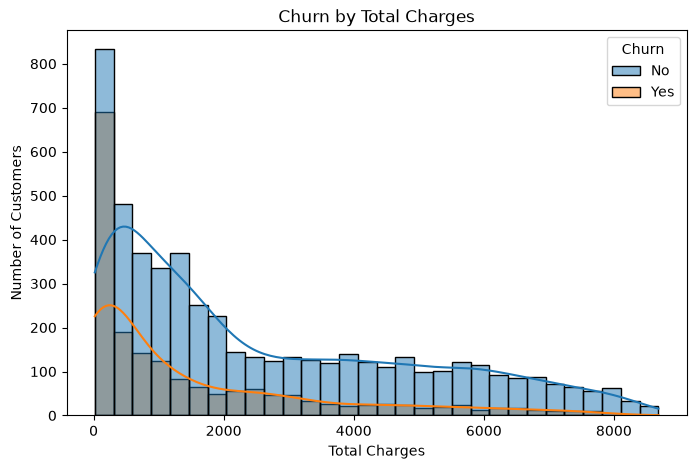

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="TotalCharges", hue="Churn", bins=30, kde=True)

plt.title("Churn by Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

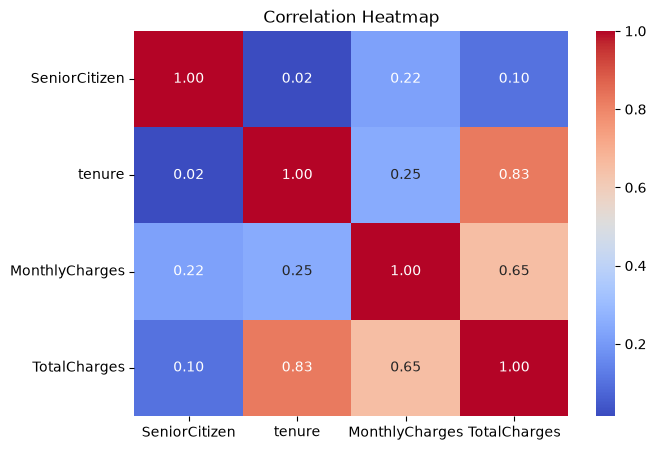

In [11]:
# Numerical columns correlation

numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [12]:
df = df.drop(columns=["customerID"])

print("Dataset Shape:", df.shape)
print(df.head())S

SyntaxError: invalid syntax (806695160.py, line 4)

In [ ]:
df = df.drop(columns=["customerID"])

print("Dataset Shape:", df.shape)
print(df.head())

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols.tolist())
S

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols.tolist())

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

In [ ]:
%pip install scikit-learn


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df.shape)

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

print("Logistic Rfrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))egression trained successfully!")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

In [ ]:
%pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Data preparation complete!
X_train: (5625, 30)
X_test: (1407, 30)


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

NameError: name 'accuracy_score' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7945984363894811
Precision: 0.6307692307692307
Recall   : 0.5481283422459893
F1 Score : 0.586552217453505
ROC-AUC  : 0.838367301510061


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.8038, 0.7683, 0.7946],
    "Precision": [0.6476, 0.5545, 0.6308],
    "Recall": [0.5749, 0.6524, 0.5481],
    "F1 Score": [0.6091, 0.5995, 0.5866],
    "ROC-AUC": [0.8357, 0.8209, 0.8384]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091,0.8357
1,Random Forest,0.7683,0.5545,0.6524,0.5995,0.8209
2,XGBoost,0.7946,0.6308,0.5481,0.5866,0.8384


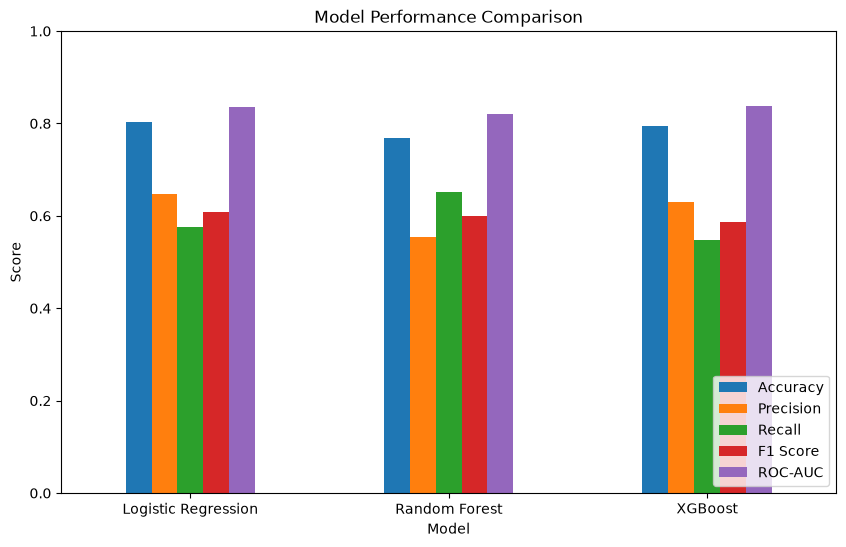

In [ ]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")

ModuleNotFoundError: No module named 'shap'

In [ ]:
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.68.0-cp314-cp314-win_amd64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.50.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
Using cached llvmlite-0.50.0-cp314-cp314-win_amd64.whl (43.0 MB)
Using cached numba-0.68.0-cp314-cp314-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ----------------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")

c:\Users\user\OneDrive\Desktop\customer-churn-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values calculated successfully!


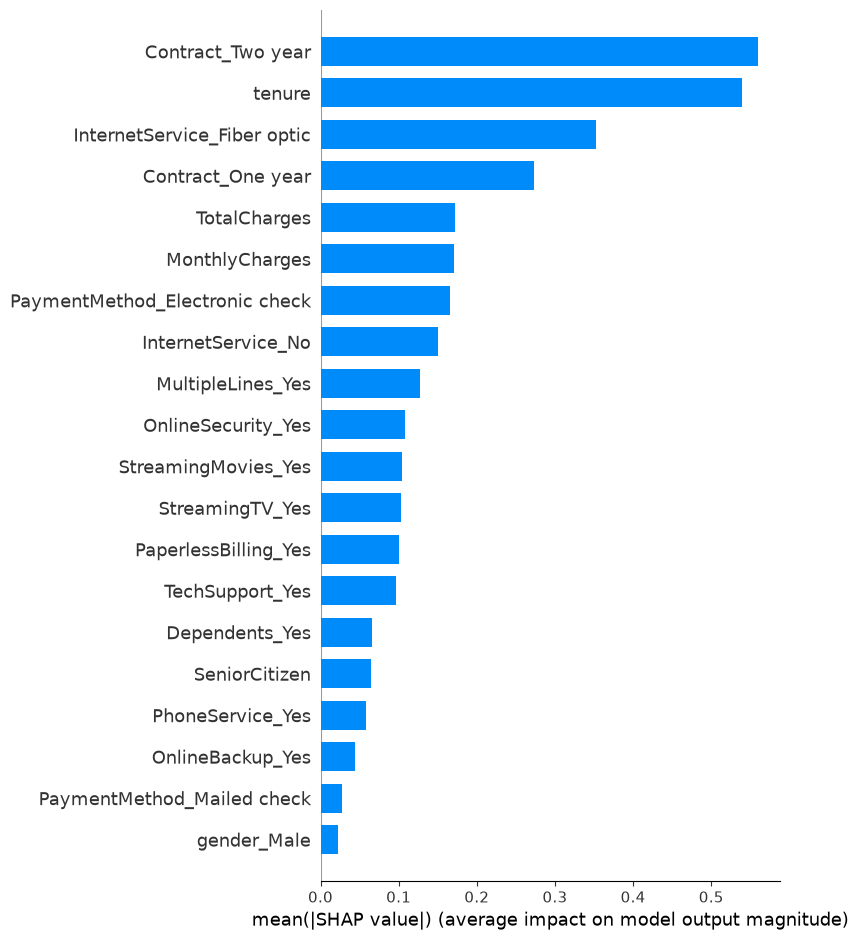

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

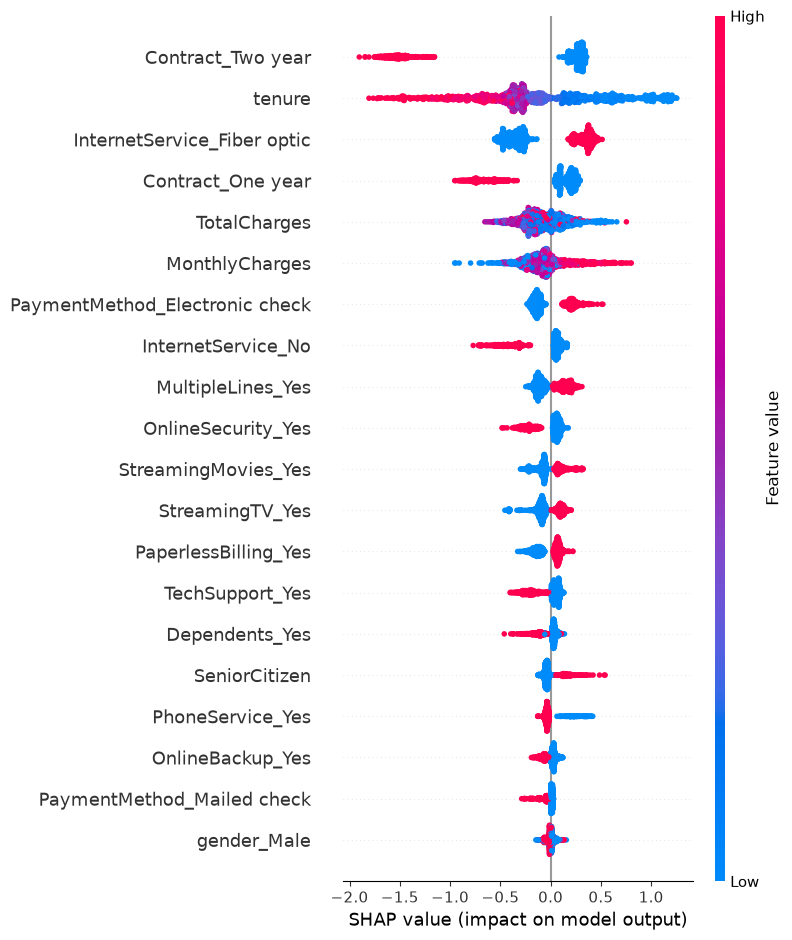

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

In [ ]:
risk_df = X_test.copy()

risk_df["Actual_Churn"] = y_test.values
risk_df["Churn_Probability"] = xgb_prob

risk_df = risk_df.sort_values(
    "Churn_Probability",
    ascending=False
)

risk_df[["Churn_Probability", "Actual_Churn"]].head(10)

,Churn_Probability,Actual_Churn
3380,0.928334,1
4585,0.916006,1
2631,0.897896,1
3727,0.894042,1
1731,0.892354,1
2900,0.885733,1
1073,0.883453,1
2753,0.882151,1
2797,0.881781,1
6240,0.880805,1


In [ ]:
risk_indices = risk_df.head(10).index

top_risk_customers = df.loc[
    risk_indices,
    [
        "gender",
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "Churn"
    ]
].copy()

top_risk_customers["Churn_Probability"] = risk_df.loc[
    risk_indices,
    "Churn_Probability"
].values

top_risk_customers

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn,Churn_Probability
3380,Male,1,1,95.10,95.10,Month-to-month,Fiber optic,Electronic check,1,0.928334
4585,Female,1,1,85.05,85.05,Month-to-month,Fiber optic,Electronic check,1,0.916006
2631,Male,1,7,99.25,665.45,Month-to-month,Fiber optic,Electronic check,1,0.897896
3727,Female,0,3,96.60,291.90,Month-to-month,Fiber optic,Electronic check,1,0.894042
1731,Female,1,1,69.60,69.60,Month-to-month,Fiber optic,Electronic check,1,0.892354
2900,Female,1,1,69.25,69.25,Month-to-month,Fiber optic,Electronic check,1,0.885733
1073,Male,0,7,98.05,713.00,Month-to-month,Fiber optic,Bank transfer (automatic),1,0.883453
2753,Female,0,1,95.65,95.65,Month-to-month,Fiber optic,Mailed check,1,0.882151
2797,Male,0,3,100.95,329.95,Month-to-month,Fiber optic,Electronic check,1,0.881781
6240,Male,0,1,93.30,93.30,Month-to-month,Fiber optic,Electronic check,1,0.880805
